In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PAP = '/content/drive/MyDrive/PERCEPCION COMPUTACIONAL - LAB: 6013/GRUPO 1/Dataset/Potato_Dataset'

for clase in sorted(os.listdir(PAP)):
    ruta = os.path.join(PAP, clase)
    if os.path.isdir(ruta):
        print(f"{clase}: {len(os.listdir(ruta))} imagenes")

import shutil
if not os.path.exists('/content/dataset_local'):
    shutil.copytree(PAP, '/content/dataset_local')

PAPA = '/content/dataset_local'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Blackspot Bruising Care: 770 imagenes
Dry Rot Care: 1355 imagenes
Healthy Potatoes: 815 imagenes
Soft Rot Care: 560 imagenes


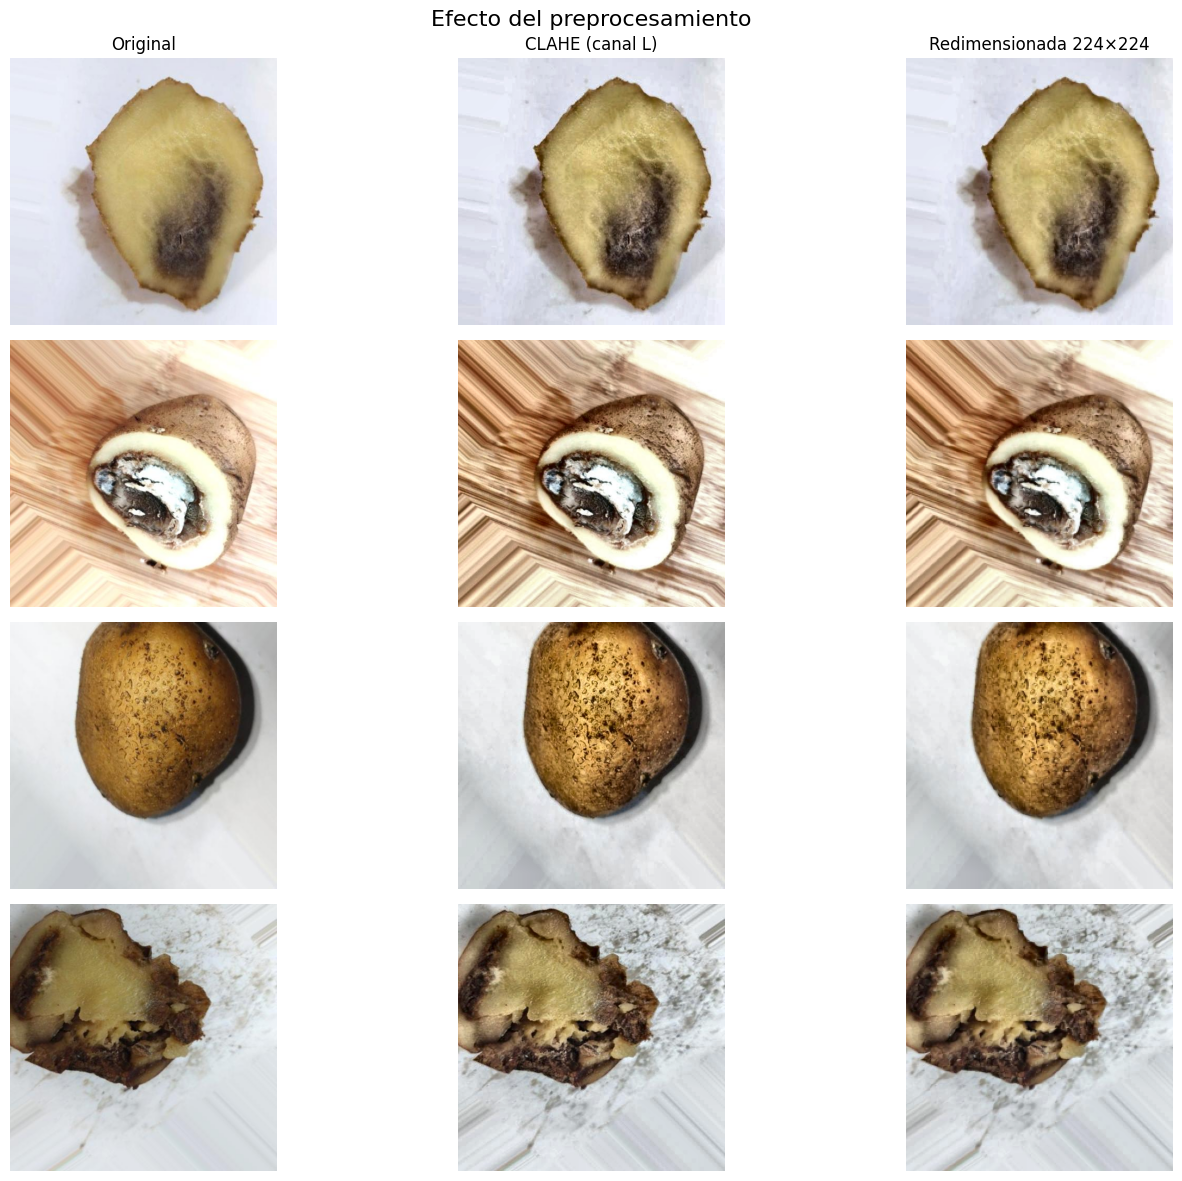

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tomar una imagen de ejemplo de cada clase
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Efecto del preprocesamiento', fontsize=16)
columnas = ['Original', 'CLAHE (canal L)', 'Redimensionada 224×224']

for i, clase in enumerate(sorted(os.listdir(PAPA))):
    ruta_clase = os.path.join(PAPA, clase)
    archivo = os.listdir(ruta_clase)[0]
    img_bgr = cv2.imread(os.path.join(ruta_clase, archivo))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 1. Original
    axes[i][0].imshow(img_rgb)
    axes[i][0].set_ylabel(clase.replace(' Care', ''), fontsize=10, fontweight='bold')

    # 2. CLAHE sobre canal L en espacio Lab
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img_clahe = cv2.cvtColor(img_lab, cv2.COLOR_Lab2RGB)
    axes[i][1].imshow(img_clahe)

    # 3. Redimensionada a 224x224 (entrada de ResNet18)
    img_resized = cv2.resize(img_clahe, (224, 224), interpolation=cv2.INTER_AREA)
    axes[i][2].imshow(img_resized)

for j, col in enumerate(columnas):
    axes[0][j].set_title(col, fontsize=12)

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('preprocesamiento_antes_despues.png', dpi=150, bbox_inches='tight')
plt.show()